# EfficientNet-B0 Partial Unfreeze + Penalty Regularization

## Motivation
ResNet18 (11M params) overfits heavily on this dataset (~5k samples, 779 melanoma). EfficientNet-B0 has ~5.3M params and we further reduce active parameters by only unfreezing the last 3 blocks of the backbone, leaving the rest frozen.

## Architecture
EfficientNet-B0 `model.features` has 9 children:
- `[0]` stem conv
- `[1ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Å“7]` MBConv blocks
- `[8]` head conv

`unfreeze_last_n_blocks=3` trains only blocks 6, 7, and head conv + classifier.

## Lambda Sweep
| Run | l1_lambda | l2_lambda | Purpose |
|-----|-----------|-----------|--------|
| 0   | 0         | 0         | Baseline (no penalty) |
| 1   | 0         | 1e-4      | Mild L2 |
| 2   | 0         | 1e-3      | Moderate L2 |
| 3   | 1e-4      | 0         | Mild L1 |
| 4   | 1e-3      | 0         | Moderate L1 |

In [30]:
import sys
import os
sys.path.append(os.path.abspath('../..'))

import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import fbeta_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

from src.data.dataloader import get_dataloaders
from src.models.efficientnet import get_efficientnet
from src.training.trainer import train_one_epoch, validate_one_epoch

In [31]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    elif torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)

set_seed(42)

In [32]:
print('CUDA available:', torch.cuda.is_available())
print('MPS available:', torch.backends.mps.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

CUDA available: True
MPS available: False
Using device: cuda


In [33]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv='../../data/splits/train.csv',
    val_csv='../../data/splits/val.csv',
    test_csv='../../data/splits/test.csv',
    image_dir='../../data/raw/HAM10000/images',
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df = pd.read_csv('../../data/splits/train.csv')
num_melanoma = (train_df['label'] == 0).sum()
num_nevus = (train_df['label'] == 1).sum()
pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)

Positive weight: tensor([6.0244], device='cuda:0')


## Lambda Sweep

In [34]:
all_results = {}

In [35]:
# --- Baseline (no penalty) ---
num_epochs = 20
run_label = 'Baseline'
l1_lambda = 0.0
l2_lambda = 0.0

print(f'=== Run: {run_label} (l1={l1_lambda}, l2={l2_lambda}) ===')
set_seed(42)

model = get_efficientnet(variant='b0', num_classes=1, unfreeze_last_n_blocks=3).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=4, factor=0.5, min_lr=1e-6)

history = {'train_loss': [], 'val_loss': [], 'train_f2': [], 'val_f2': []}
best_val_f2 = 0.0
best_state = None

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device, l1_lambda=l1_lambda, l2_lambda=l2_lambda)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_f2'].append(train_metrics['f2'])
    history['val_f2'].append(val_metrics['f2'])

    scheduler.step(val_metrics['f2'])
    current_lr = optimizer.param_groups[0]['lr']

    print(f"  Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_metrics['loss']:.4f}, F2: {train_metrics['f2']:.4f} | Val Loss: {val_metrics['loss']:.4f}, F2: {val_metrics['f2']:.4f} | LR: {current_lr:.2e}")

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f'    -> New best val F2: {best_val_f2:.4f}')

all_results[run_label] = {'history': history, 'best_val_f2': best_val_f2, 'best_state': best_state}
print(f'Best val F2 for {run_label}: {best_val_f2:.4f}')

=== Run: Baseline (l1=0.0, l2=0.0) ===


  Epoch [1/20] | Train Loss: 0.7817, F2: 0.6505 | Val Loss: 0.6553, F2: 0.7102 | LR: 1.00e-04
    -> New best val F2: 0.7102


  Epoch [2/20] | Train Loss: 0.5757, F2: 0.7337 | Val Loss: 0.6148, F2: 0.7045 | LR: 1.00e-04


  Epoch [3/20] | Train Loss: 0.4857, F2: 0.7797 | Val Loss: 0.6447, F2: 0.6950 | LR: 1.00e-04


  Epoch [4/20] | Train Loss: 0.4289, F2: 0.8038 | Val Loss: 0.5673, F2: 0.7341 | LR: 1.00e-04
    -> New best val F2: 0.7341


...

  Epoch [16/20] | Train Loss: 0.1217, F2: 0.9483 | Val Loss: 0.9336, F2: 0.6982 | LR: 5.00e-05


  Epoch [17/20] | Train Loss: 0.1157, F2: 0.9453 | Val Loss: 0.8857, F2: 0.7241 | LR: 5.00e-05


  Epoch [18/20] | Train Loss: 0.0942, F2: 0.9599 | Val Loss: 0.8527, F2: 0.7556 | LR: 5.00e-05


  Epoch [19/20] | Train Loss: 0.0971, F2: 0.9604 | Val Loss: 0.8999, F2: 0.7414 | LR: 5.00e-05


  Epoch [20/20] | Train Loss: 0.1000, F2: 0.9552 | Val Loss: 0.9210, F2: 0.7268 | LR: 5.00e-05
Best val F2 for Baseline: 0.7727


In [36]:
# --- L2=1e-3 ---
num_epochs = 20
run_label = 'L2=1e-3'
l1_lambda = 0.0
l2_lambda = 1e-3

print(f'=== Run: {run_label} (l1={l1_lambda}, l2={l2_lambda}) ===')
set_seed(42)

model = get_efficientnet(variant='b0', num_classes=1, unfreeze_last_n_blocks=1).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=4, factor=0.5, min_lr=1e-6)

history = {'train_loss': [], 'val_loss': [], 'train_f2': [], 'val_f2': []}
best_val_f2 = 0.0
best_state = None

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device, l1_lambda=l1_lambda, l2_lambda=l2_lambda)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_f2'].append(train_metrics['f2'])
    history['val_f2'].append(val_metrics['f2'])

    scheduler.step(val_metrics['f2'])
    current_lr = optimizer.param_groups[0]['lr']

    print(f"  Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_metrics['loss']:.4f}, F2: {train_metrics['f2']:.4f} | Val Loss: {val_metrics['loss']:.4f}, F2: {val_metrics['f2']:.4f} | LR: {current_lr:.2e}")

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f'    -> New best val F2: {best_val_f2:.4f}')

all_results[run_label] = {'history': history, 'best_val_f2': best_val_f2, 'best_state': best_state}
print(f'Best val F2 for {run_label}: {best_val_f2:.4f}')

=== Run: L2=1e-3 (l1=0.0, l2=0.001) ===


  Epoch [1/20] | Train Loss: 0.9511, F2: 0.6082 | Val Loss: 0.8283, F2: 0.6714 | LR: 1.00e-04
    -> New best val F2: 0.6714


  Epoch [2/20] | Train Loss: 0.7705, F2: 0.6743 | Val Loss: 0.7564, F2: 0.6611 | LR: 1.00e-04


  Epoch [3/20] | Train Loss: 0.7098, F2: 0.6964 | Val Loss: 0.7236, F2: 0.6990 | LR: 1.00e-04
    -> New best val F2: 0.6990


  Epoch [4/20] | Train Loss: 0.6786, F2: 0.6975 | Val Loss: 0.6902, F2: 0.6862 | LR: 1.00e-04


...

  Epoch [16/20] | Train Loss: 0.4894, F2: 0.7847 | Val Loss: 0.6502, F2: 0.7004 | LR: 5.00e-05


  Epoch [17/20] | Train Loss: 0.5036, F2: 0.7754 | Val Loss: 0.6426, F2: 0.7062 | LR: 5.00e-05


  Epoch [18/20] | Train Loss: 0.4920, F2: 0.7872 | Val Loss: 0.6442, F2: 0.6984 | LR: 2.50e-05


  Epoch [19/20] | Train Loss: 0.4829, F2: 0.7782 | Val Loss: 0.6337, F2: 0.7041 | LR: 2.50e-05


  Epoch [20/20] | Train Loss: 0.4846, F2: 0.7861 | Val Loss: 0.6424, F2: 0.7010 | LR: 2.50e-05
Best val F2 for L2=1e-3: 0.7084


In [37]:
# --- L1=1e-3 ---
num_epochs = 20
run_label = 'L1=1e-3'
l1_lambda = 1e-3
l2_lambda = 0.0

print(f'=== Run: {run_label} (l1={l1_lambda}, l2={l2_lambda}) ===')
set_seed(42)

model = get_efficientnet(variant='b0', num_classes=1, unfreeze_last_n_blocks=1).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=4, factor=0.5, min_lr=1e-6)

history = {'train_loss': [], 'val_loss': [], 'train_f2': [], 'val_f2': []}
best_val_f2 = 0.0
best_state = None

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device, l1_lambda=l1_lambda, l2_lambda=l2_lambda)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_f2'].append(train_metrics['f2'])
    history['val_f2'].append(val_metrics['f2'])

    scheduler.step(val_metrics['f2'])
    current_lr = optimizer.param_groups[0]['lr']

    print(f"  Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_metrics['loss']:.4f}, F2: {train_metrics['f2']:.4f} | Val Loss: {val_metrics['loss']:.4f}, F2: {val_metrics['f2']:.4f} | LR: {current_lr:.2e}")

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f'    -> New best val F2: {best_val_f2:.4f}')

all_results[run_label] = {'history': history, 'best_val_f2': best_val_f2, 'best_state': best_state}
print(f'Best val F2 for {run_label}: {best_val_f2:.4f}')

=== Run: L1=1e-3 (l1=0.001, l2=0.0) ===


  Epoch [1/20] | Train Loss: 1.0035, F2: 0.5888 | Val Loss: 0.8938, F2: 0.6444 | LR: 1.00e-04
    -> New best val F2: 0.6444


  Epoch [2/20] | Train Loss: 0.8281, F2: 0.6640 | Val Loss: 0.8059, F2: 0.6608 | LR: 1.00e-04
    -> New best val F2: 0.6608


  Epoch [3/20] | Train Loss: 0.7588, F2: 0.6877 | Val Loss: 0.7646, F2: 0.6722 | LR: 1.00e-04
    -> New best val F2: 0.6722


  Epoch [4/20] | Train Loss: 0.7233, F2: 0.6863 | Val Loss: 0.7247, F2: 0.6704 | LR: 1.00e-04


...

  Epoch [16/20] | Train Loss: 0.5755, F2: 0.7411 | Val Loss: 0.6789, F2: 0.6890 | LR: 1.00e-04


  Epoch [17/20] | Train Loss: 0.5884, F2: 0.7324 | Val Loss: 0.6338, F2: 0.6924 | LR: 1.00e-04


  Epoch [18/20] | Train Loss: 0.5740, F2: 0.7488 | Val Loss: 0.6539, F2: 0.6995 | LR: 5.00e-05


  Epoch [19/20] | Train Loss: 0.5523, F2: 0.7508 | Val Loss: 0.6240, F2: 0.7107 | LR: 5.00e-05


  Epoch [20/20] | Train Loss: 0.5549, F2: 0.7490 | Val Loss: 0.6369, F2: 0.6993 | LR: 5.00e-05
Best val F2 for L1=1e-3: 0.7178


In [48]:
# --- L1=1e-3 and L2=1e-3 ---
num_epochs = 40
run_label = 'L1=1e-3, L2=1e-3'
l1_lambda = 1e-3
l2_lambda = 1e-3

print(f'=== Run: {run_label} (l1={l1_lambda}, l2={l2_lambda}) ===')
set_seed(42)

model = get_efficientnet(variant='b0', num_classes=1, unfreeze_last_n_blocks=1).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=4, factor=0.5, min_lr=1e-6)

history = {'train_loss': [], 'val_loss': [], 'train_f2': [], 'val_f2': []}
best_val_f2 = 0.0
best_state = None

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device, l1_lambda=l1_lambda, l2_lambda=l2_lambda)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_f2'].append(train_metrics['f2'])
    history['val_f2'].append(val_metrics['f2'])

    scheduler.step(val_metrics['f2'])
    current_lr = optimizer.param_groups[0]['lr']

    print(f"  Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_metrics['loss']:.4f}, F2: {train_metrics['f2']:.4f} | Val Loss: {val_metrics['loss']:.4f}, F2: {val_metrics['f2']:.4f} | LR: {current_lr:.2e}")

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f'    -> New best val F2: {best_val_f2:.4f}')

all_results[run_label] = {'history': history, 'best_val_f2': best_val_f2, 'best_state': best_state}
print(f'Best val F2 for {run_label}: {best_val_f2:.4f}')

=== Run: L1=1e-3, L2=1e-3 (l1=0.001, l2=0.001) ===


  Epoch [1/40] | Train Loss: 1.0101, F2: 0.5855 | Val Loss: 0.9029, F2: 0.6433 | LR: 1.00e-04
    -> New best val F2: 0.6433


  Epoch [2/40] | Train Loss: 0.8369, F2: 0.6633 | Val Loss: 0.8143, F2: 0.6612 | LR: 1.00e-04
    -> New best val F2: 0.6612


  Epoch [3/40] | Train Loss: 0.7669, F2: 0.6861 | Val Loss: 0.7726, F2: 0.6697 | LR: 1.00e-04
    -> New best val F2: 0.6697


  Epoch [4/40] | Train Loss: 0.7307, F2: 0.6834 | Val Loss: 0.7320, F2: 0.6761 | LR: 1.00e-04
    -> New best val F2: 0.6761


...

  Epoch [36/40] | Train Loss: 0.5042, F2: 0.7784 | Val Loss: 0.6151, F2: 0.7098 | LR: 1.25e-05


  Epoch [37/40] | Train Loss: 0.4820, F2: 0.7884 | Val Loss: 0.6252, F2: 0.7068 | LR: 1.25e-05


  Epoch [38/40] | Train Loss: 0.4906, F2: 0.7905 | Val Loss: 0.6109, F2: 0.7180 | LR: 1.25e-05


  Epoch [39/40] | Train Loss: 0.4739, F2: 0.7941 | Val Loss: 0.6223, F2: 0.7121 | LR: 6.25e-06


  Epoch [40/40] | Train Loss: 0.4820, F2: 0.7963 | Val Loss: 0.6189, F2: 0.7173 | LR: 6.25e-06
Best val F2 for L1=1e-3, L2=1e-3: 0.7222


## Compare Overfitting: Train vs Val F2 Gap

In [53]:
print(f"{'Run':<12} | {'Best Val F2':>11} | {'Final Train F2':>14} | {'Final Val F2':>12} | {'Gap (T-V)':>9}")
print('-' * 70)
for run_label, result in all_results.items():
    h = result['history']
    final_train_f2 = h['train_f2'][-1]
    final_val_f2 = h['val_f2'][-1]
    gap = final_train_f2 - final_val_f2
    print(f"{run_label:<12} | {result['best_val_f2']:>11.4f} | {final_train_f2:>14.4f} | {final_val_f2:>12.4f} | {gap:>9.4f}")

Run          | Best Val F2 | Final Train F2 | Final Val F2 | Gap (T-V)
----------------------------------------------------------------------
Baseline     |      0.7727 |         0.9552 |       0.7268 |    0.2283
L2=1e-3      |      0.7084 |         0.7861 |       0.7010 |    0.0850
L1=1e-3      |      0.7178 |         0.7490 |       0.6993 |    0.0497
L1=1e-3, L2=1e-3 |      0.7222 |         0.7963 |       0.7173 |    0.0791


## Compare Overfitting: Train vs Val Loss Gap

In [52]:
print(f"{'Run':<12} | {'Final Train Loss':>15} | {'Final Val Loss':>14} | {'Loss Gap (V-T)':>14}")
print("-" * 62)
for run_label, result in all_results.items():
    h = result["history"]
    final_train_loss = h["train_loss"][-1]
    final_val_loss = h["val_loss"][-1]
    gap = final_val_loss - final_train_loss
    print(f"{run_label:<12} | {final_train_loss:>15.4f} | {final_val_loss:>14.4f} | {gap:>14.4f}")


Run          | Final Train Loss | Final Val Loss | Loss Gap (V-T)
--------------------------------------------------------------
Baseline     |          0.1000 |         0.9210 |         0.8209
L2=1e-3      |          0.4846 |         0.6424 |         0.1577
L1=1e-3      |          0.5549 |         0.6369 |         0.0820
L1=1e-3, L2=1e-3 |          0.4820 |         0.6189 |         0.1369


## Compare Test Loss, Recall and F2 for all Runs

In [54]:
from sklearn.metrics import recall_score

print(f"{'Run':<12} | {'Test Loss':>9} | {'Test Recall':>11} | {'Test F2':>9}")
print('-' * 50)

for run_label, result in all_results.items():
    eval_model = get_efficientnet(variant='b0', num_classes=1, unfreeze_last_n_blocks=3).to(device)
    eval_model.load_state_dict({k: v.to(device) for k, v in result['best_state'].items()})
    eval_model.eval()

    criterion_eval = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    running_loss = 0.0
    total_samples = 0
    all_labels_test = []
    all_probs_test = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels_dev = labels.float().unsqueeze(1).to(device)
            outputs = eval_model(images)
            loss = criterion_eval(outputs, labels_dev)
            running_loss += loss.item() * images.size(0)
            total_samples += images.size(0)
            probs = torch.sigmoid(outputs).squeeze(1)
            all_probs_test.extend(probs.cpu().numpy())
            all_labels_test.extend(labels.numpy())

    test_loss = running_loss / total_samples

    val_probs_run, val_labels_run = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = eval_model(images.to(device))
            probs = torch.sigmoid(outputs).squeeze(1)
            val_probs_run.extend(probs.cpu().numpy())
            val_labels_run.extend(labels.numpy())

    thresholds = np.arange(0.01, 0.9, 0.01)
    f2_scores = [fbeta_score(val_labels_run, (np.array(val_probs_run) >= t).astype(int), beta=2, pos_label=1, zero_division=0) for t in thresholds]
    best_threshold = thresholds[np.argmax(f2_scores)]

    preds = (np.array(all_probs_test) >= best_threshold).astype(int)
    test_f2 = fbeta_score(all_labels_test, preds, beta=2, pos_label=1, zero_division=0)
    test_recall = recall_score(all_labels_test, preds, pos_label=1, zero_division=0)

    print(f"{run_label:<12} | {test_loss:>9.4f} | {test_recall:>11.4f} | {test_f2:>9.4f}")

Run          | Test Loss | Test Recall |   Test F2
--------------------------------------------------
Baseline     |    0.8276 |      0.7485 |    0.7234
L2=1e-3      |    0.7157 |      0.8323 |    0.6957
L1=1e-3      |    0.7119 |      0.7904 |    0.6694
L1=1e-3, L2=1e-3 |    0.6823 |      0.7904 |    0.6769


## Training Curves

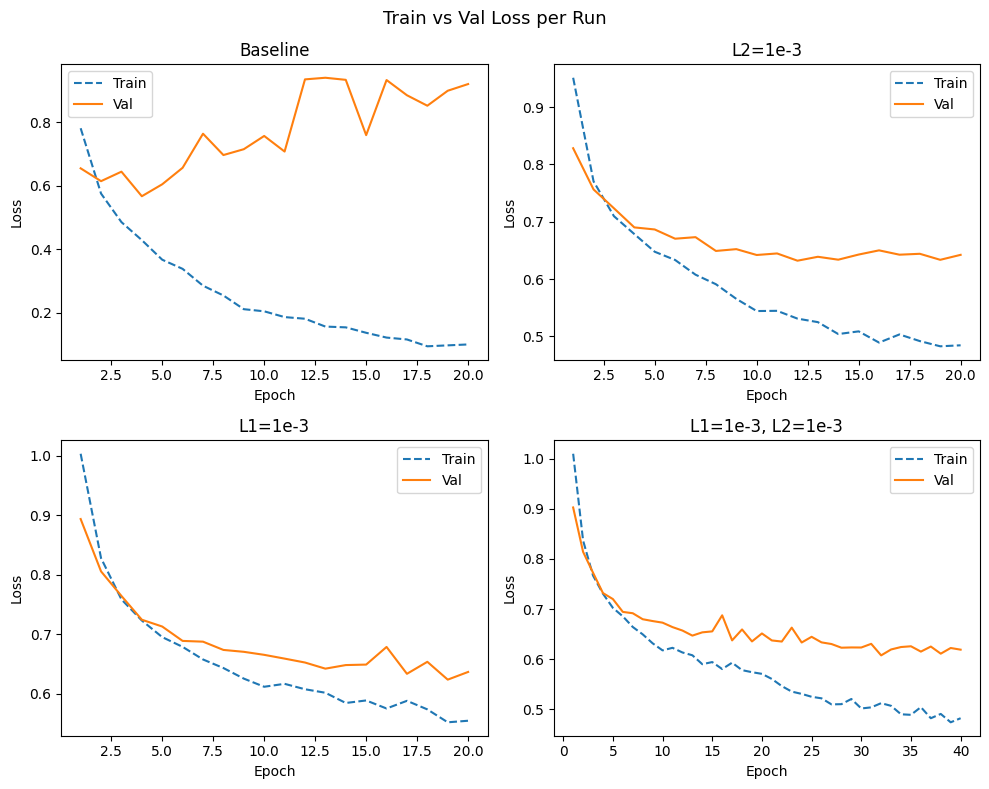

In [56]:
n_runs = len(all_results)
n_cols = 2
n_rows = (n_runs + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows), sharey=False)
axes = axes.flatten()

for ax, (run_label, result) in zip(axes, all_results.items()):
    h = result['history']
    epochs = range(1, len(h['train_loss']) + 1)
    ax.plot(epochs, h['train_loss'], label='Train', linestyle='--')
    ax.plot(epochs, h['val_loss'], label='Val')
    ax.set_title(run_label)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

for ax in axes[n_runs:]:
    ax.set_visible(False)

fig.suptitle('Train vs Val Loss per Run', fontsize=13)
plt.tight_layout()
plt.show()

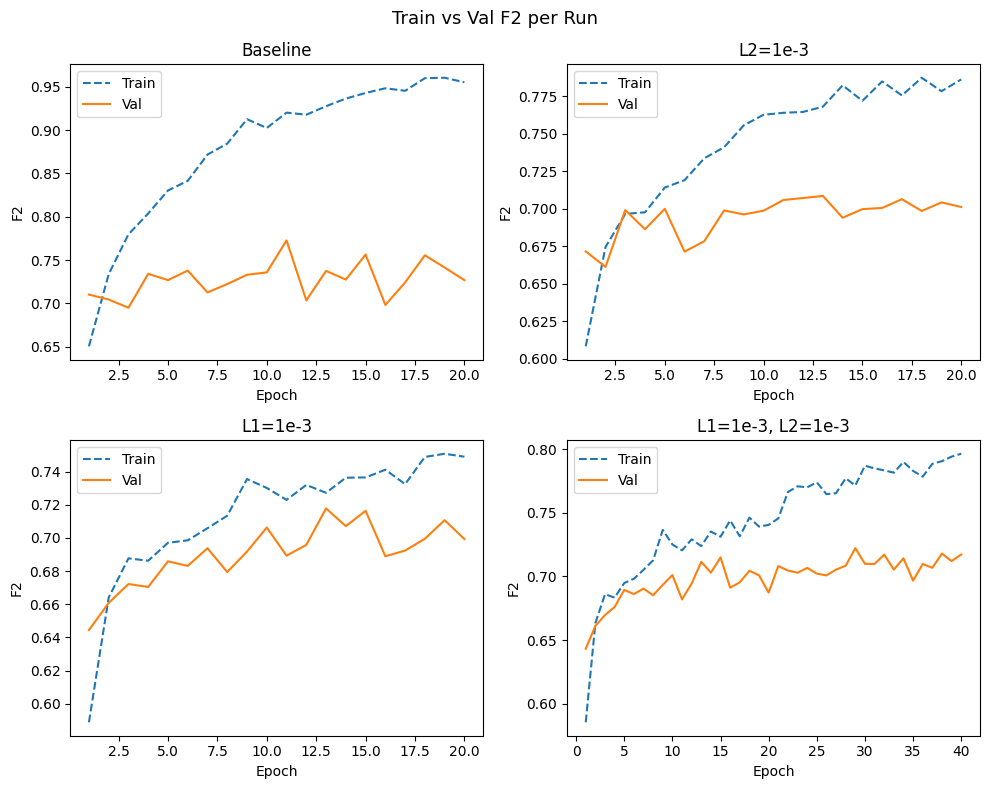

In [57]:
n_runs = len(all_results)
n_cols = 2
n_rows = (n_runs + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows), sharey=False)
axes = axes.flatten()

for ax, (run_label, result) in zip(axes, all_results.items()):
    h = result['history']
    epochs = range(1, len(h['train_f2']) + 1)
    ax.plot(epochs, h['train_f2'], label='Train', linestyle='--')
    ax.plot(epochs, h['val_f2'], label='Val')
    ax.set_title(run_label)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('F2')
    ax.legend()

for ax in axes[n_runs:]:
    ax.set_visible(False)

fig.suptitle('Train vs Val F2 per Run', fontsize=13)
plt.tight_layout()
plt.show()

## Save & Evaluate Best Run

In [58]:
best_run_label = max(all_results, key=lambda k: all_results[k]['best_val_f2'])
print(f'Best run: {best_run_label} (val F2 = {all_results[best_run_label]["best_val_f2"]:.4f})')

best_model = get_efficientnet(variant='b0', num_classes=1, unfreeze_last_n_blocks=3).to(device)
best_model.load_state_dict({k: v.to(device) for k, v in all_results[best_run_label]['best_state'].items()})

torch.save(best_model.state_dict(), '../../models/efficientnet_b0_partial_unfreeze_penalty_best.pth')
print('Saved to models/efficientnet_b0_partial_unfreeze_penalty_best.pth')

Best run: Baseline (val F2 = 0.7727)
Saved to models/efficientnet_b0_partial_unfreeze_penalty_best.pth


## Threshold Tuning

In [59]:
best_model.eval()

val_probs = []
val_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = best_model(images.to(device))
        probs = torch.sigmoid(outputs).squeeze(1)
        val_probs.extend(probs.cpu().numpy())
        val_labels.extend(labels.numpy())

thresholds = np.arange(0.01, 0.9, 0.01)
f2_scores = [
    fbeta_score(val_labels, (np.array(val_probs) >= t).astype(int), beta=2, pos_label=1, zero_division=0)
    for t in thresholds
]

best_threshold = thresholds[np.argmax(f2_scores)]
print(f'Best threshold: {best_threshold:.2f} | Val F2: {max(f2_scores):.4f}')

Best threshold: 0.53 | Val F2: 0.7754


## Test Set Evaluation

In [60]:
best_model.eval()

all_labels = []
all_probs = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = best_model(images)
        probs = torch.sigmoid(outputs).squeeze(1)
        preds = (probs >= best_threshold).long()

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print('Confusion Matrix:')
print(cm)
print()
print(classification_report(all_labels, all_preds, digits=4))

Confusion Matrix:
[[935  71]
 [ 42 125]]

              precision    recall  f1-score   support

           0     0.9570    0.9294    0.9430      1006
           1     0.6378    0.7485    0.6887       167

    accuracy                         0.9037      1173
   macro avg     0.7974    0.8390    0.8159      1173
weighted avg     0.9116    0.9037    0.9068      1173



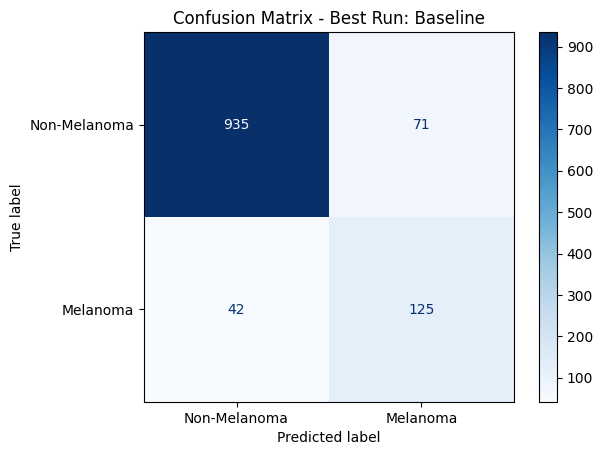

In [62]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Melanoma', 'Melanoma'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix - Best Run: {best_run_label}')
plt.show()